<a href="https://colab.research.google.com/github/vinayprajapati456/BTP_2026/blob/main/Transformer_base_img.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install transformers datasets torchvision pillow

Import Modules for ViT-GPT2 Model

This cell imports the necessary modules for the first image captioning model, which is a combination of a Vision Transformer (ViT) encoder and a GPT-2 decoder:

*   `torch`: The main PyTorch library for deep learning operations.
*   `PIL.Image`: Used for opening, manipulating, and saving image files.
*   `requests`: A library for making HTTP requests, used here to download images from URLs.
*   `transformers.VisionEncoderDecoderModel`: The class for models that combine an encoder (like ViT) and a decoder (like GPT-2).
*   `transformers.ViTImageProcessor`: A preprocessor specifically designed for the Vision Transformer model to prepare images for input.
*   `transformers.AutoTokenizer`: A general-purpose tokenizer class that can load the appropriate tokenizer for a given pre-trained model (in this case, for GPT-2).

In [10]:
import torch
from PIL import Image
import requests

from transformers import VisionEncoderDecoderModel
from transformers import ViTImageProcessor, AutoTokenizer

### Load ViT-GPT2 Model and Components

This cell performs the following crucial steps:

1.  **Load `VisionEncoderDecoderModel`**: It loads the pre-trained `nlpconnect/vit-gpt2-image-captioning` model. This model is designed to take an image as input and generate a textual caption.
2.  **Load `ViTImageProcessor`**: It loads the corresponding image processor, which handles tasks like resizing, normalization, and converting images into a format suitable for the ViT encoder.
3.  **Load `AutoTokenizer`**: It loads the tokenizer for the GPT-2 decoder part of the model, which converts text (for generation) to token IDs and vice versa.
4.  **Device Setup**: It determines whether a GPU (`cuda`) is available and sets the `device` accordingly. The model is then moved to this device for computation, leveraging GPU acceleration if available.

In [11]:
model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

feature_extractor = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (inte

 Define Caption Generation Function

This cell sets up parameters for caption generation and defines a helper function:

*   `max_length`: The maximum length of the generated caption (in tokens).
*   `num_beams`: The number of beams to use for beam search during text generation. Beam search explores multiple possible sequences to find a high-probability one, often leading to better quality captions.
*   `gen_kwargs`: A dictionary to pass these generation parameters to the model's `generate` method.
*   `generate_caption(image_path)` function:
    *   Opens an image from the given `image_path` and converts it to RGB format.
    *   Uses the `feature_extractor` to preprocess the image and converts it into a PyTorch tensor, moving it to the designated `device`.
    *   Calls `model.generate()` with the processed image pixels and generation arguments (`gen_kwargs`) to get the output token IDs.
    *   Decodes these token IDs back into a human-readable string using the `tokenizer`, skipping special tokens (like `[CLS]`, `[SEP]`).
    *   Returns the generated caption.

In [12]:
max_length = 16
num_beams = 4

gen_kwargs = {
    "max_length": max_length,
    "num_beams": num_beams
}

def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")

    pixel_values = feature_extractor(images=image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    output_ids = model.generate(pixel_values, **gen_kwargs)

    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return caption

 Demonstrate ViT-GPT2 Captioning

This cell demonstrates the ViT-GPT2 image captioning model in action:

1.  **Import `matplotlib.pyplot`**: Used for plotting images.
2.  **Load Image from URL**: Downloads an image of a cat from a specified URL using `requests` and opens it with `PIL.Image`.
3.  **Save Image (Optional)**: Saves the downloaded image locally as `test.jpg`. This is useful if you want to reuse the image or inspect it.
4.  **Generate Caption**: Calls the `generate_caption` function defined earlier with the path to the saved image (`test.jpg`).
5.  **Display Image and Caption**: Uses `matplotlib` to display the image and overlays the generated caption as the plot title. `plt.axis("off")` removes the axes for a cleaner look.

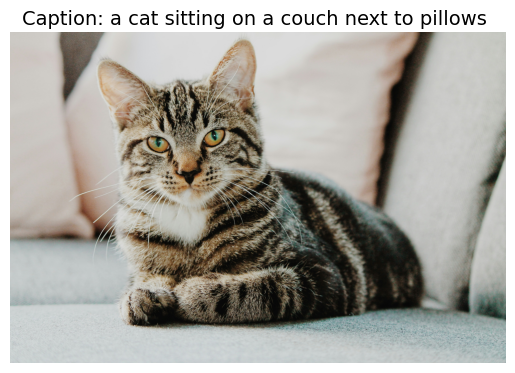

In [13]:
import matplotlib.pyplot as plt

# Load image from URL
url = "https://images.unsplash.com/photo-1518791841217-8f162f1e1131"
image = Image.open(requests.get(url, stream=True).raw)

# Save (optional)
image.save("test.jpg")

# Generate caption
caption = generate_caption("test.jpg")

# Display image + caption
plt.imshow(image)
plt.axis("off")
plt.title(f"Caption: {caption}", fontsize=14)
plt.show()

 Customized Caption Display

This cell provides an alternative way to display the image and its caption, offering more control over the caption's placement:

*   It creates a new `matplotlib` figure and displays the `image`.
*   `plt.axis("off")` is used again to remove the axes.
*   `plt.text()` is used to place the caption at a specific position relative to the axes. The `transform=plt.gca().transAxes` argument ensures the coordinates (0.5, -0.1) are relative to the figure's axes, placing the text horizontally centered below the image. `ha='center'` horizontally aligns the text in the center.

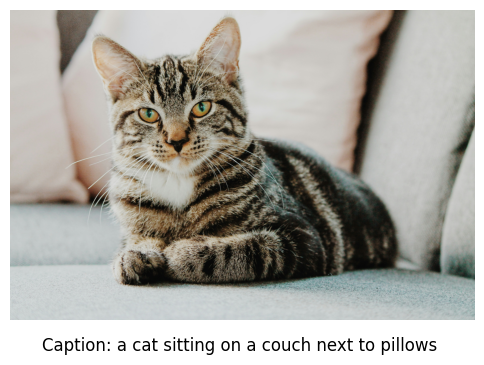

In [14]:
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")

plt.text(
    0.5, -0.1,
    f"Caption: {caption}",
    fontsize=12,
    ha='center',
    transform=plt.gca().transAxes
)

plt.show()

Install Additional Libraries for BLIP-2 and Gradio

This cell installs more libraries needed for the second image captioning model (BLIP-2) and for creating a web-based user interface:

*   `transformers`: (Already installed, but listed again for completeness) For the BLIP-2 model.
*   `accelerate`: A Hugging Face library to easily run PyTorch models on different hardware (CPUs, GPUs, TPUs) with minimal code changes.
*   `gradio`: A library for quickly building customizable UI components around machine learning models, allowing for easy demonstration and interaction.

In [15]:
!pip install transformers accelerate gradio pillow

 Implement BLIP-2 Model with Gradio Interface

This cell sets up and demonstrates another, more advanced, image captioning model called BLIP-2, and wraps it in a Gradio user interface:

1.  **Import Modules**: Imports `torch`, `PIL.Image`, `transformers.Blip2Processor`, `transformers.Blip2ForConditionalGeneration`, and `gradio`.
2.  **Device Setup**: Similar to before, it determines the available device (`cuda` or `cpu`).
3.  **Load BLIP-2 Model**: It loads the `Salesforce/blip2-opt-2.7b` model and its corresponding `Blip2Processor`. BLIP-2 is known for its strong performance in vision-language tasks. It sets `torch_dtype` to `float16` for CUDA to save memory and speed up computation.
4.  **`generate_caption(image)` function**: This function is specifically designed for the BLIP-2 model:
    *   It takes an `image` (PIL Image object) as input.
    *   Uses the `processor` to prepare the image for the BLIP-2 model.
    *   Calls `model.generate()` to produce caption token IDs, with `max_new_tokens=20` to control caption length.
    *   Decodes the generated IDs into a readable string.
5.  **Gradio UI**:
    *   An `interface` object is created using `gradio.Interface`.
    *   `fn=generate_caption`: Specifies the Python function to be called when the UI is interacted with.
    *   `inputs=gr.Image(type="pil")`: Defines an image input component, expecting a PIL Image object.
    *   `outputs=gr.Textbox(label="Generated Caption")`: Defines a text box output component to display the caption.
    *   `title` and `description`: Provide metadata for the Gradio app.
    *   `interface.launch()`: Starts the Gradio web server, making the interactive UI available in the Colab output.

In [1]:
import torch
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import gradio as gr

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load model
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)

# Caption function
def generate_caption(image):
    inputs = processor(images=image, return_tensors="pt").to(device)
    generated_ids = model.generate(**inputs, max_new_tokens=20)
    caption = processor.decode(generated_ids[0], skip_special_tokens=True)
    return caption

# Gradio UI
interface = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="pil"),
    outputs=gr.Textbox(label="Generated Caption"),
    title="AI Image Captioning",
    description="Upload an image and get an AI-generated caption using BLIP-2"
)

interface.launch()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fedc05a8275c584843.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
